<a href="https://colab.research.google.com/github/isocan/ML-accelerated-ORR/blob/main/notebooks/04_stageIII_real_VASP_ORR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/isocan/ML-accelerated-ORR/blob/main/notebooks/04_stageIII_real_VASP_ORR_publication_ready.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/></a>

# Stage III — VASP/VaspGibbs/VASPsol ORR thermodynamics

## Publication-ready demonstration with `mp-12608_111` and Pt(111)

This notebook demonstrates the final thermodynamic stage of the multi-fidelity
ORR workflow using **real VASP output files committed to the GitHub repository**.

It performs five transparent operations:

1. reads the final `energy(sigma->0)` from each VASP `OUTCAR` and uses ASE for forces;
2. reads final structures from `CONTCAR` and displays the bare slab, O*, OH*,
   and OOH* intermediates with py3Dmol;
3. constructs each state free energy as `G_state = E_sigma→0 + (G - E_DFT)`;
4. calculates vacuum and implicit-solvent adsorption Gibbs free energies,
   limiting potential, PDS, and ORR overpotential;
5. compares the candidate directly with the calculated `mp-126_111` Pt(111)
   reference and exports publication figures and CSV tables.

The notebook does not generate synthetic `OUTCAR` files and does not access the
author's Google Drive. Every required source file is read from the cloned public
repository.

### Scientific references

- ASE file I/O: https://ase-lib.org/ase/io/io.html
- VASP OUTCAR: https://vasp.at/wiki/OUTCAR
- VaspGibbs: https://pypi.org/project/VaspGibbs/
- VASPsol: https://vasp.at/info/resource/vaspsol/
- ORR computational hydrogen electrode framework:
  https://doi.org/10.1021/jp047349j

### Thermodynamic convention used in this notebook

- The last `energy(sigma->0)` value is used for every vacuum and solvent state.
- The corresponding vacuum `Freq_vac/VaspGibbs.md` correction is added to that state.
- H₂ and H₂O are always taken from their vacuum `Freq_vac` calculations.
- Molecular `Sol/OUTCAR` files are not used as CHE references.


## 1. Required public-data layout

Only the files shown below are used. Surface `Freq_vac/OUTCAR`, `ACF.dat`,
Bader folders, `CHGCAR`, `WAVECAR`, and molecular `Sol/OUTCAR` files are not
used by this notebook.

```text
data/stageIII_vasp_demo/
├── Molecules/
│   ├── H2/
│   │   └── Freq_vac/
│   │       ├── OUTCAR
│   │       └── VaspGibbs.md
│   └── H2O/
│       └── Freq_vac/
│           ├── OUTCAR
│           └── VaspGibbs.md
├── mp-12608_111/
│   ├── Slab/
│   │   ├── OUTCAR
│   │   ├── CONTCAR
│   │   ├── Freq_vac/VaspGibbs.md
│   │   └── Sol/OUTCAR
│   ├── O/...
│   ├── OH/...
│   └── OOH/...
└── mp-126_111/
    ├── Slab/...
    ├── O/...
    ├── OH/...
    └── OOH/...
```

`mp-12608_111` is the demonstration candidate and `mp-126_111` is the
calculated Pt(111) reference.

For every state:

\[
G_{\mathrm{state}}
=
E_{\sigma\rightarrow 0}
+
\left(G-E_{\mathrm{DFT}}\right).
\]

The vacuum H₂ and H₂O state free energies define the CHE references for both
the vacuum and solvent-aware surface calculations.

In [1]:
# Lightweight, reproducible post-processing environment.
%pip -q install "ase==3.26.0" "py3Dmol>=2.4,<3" "pandas>=2.2,<3" "matplotlib>=3.9,<4"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 33.1 MB/s eta 0:00:00


In [2]:
from __future__ import annotations

from pathlib import Path
import io
import json
import re
import shutil
import subprocess
import sys
import warnings
from typing import Any

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
import py3Dmol

from ase import Atoms
from ase.io import read, write
from ase.visualize.plot import plot_atoms
from IPython.display import display

## 2. Clone the repository and define the worked example

In [3]:
IN_COLAB = "google.colab" in sys.modules

REPO_URL = "https://github.com/isocan/ML-accelerated-ORR.git"
REPO_REF = "main"

CANDIDATE = "mp-12608_111"
PT_REFERENCE = "mp-126_111"

if IN_COLAB:
    REPO_ROOT = Path("/content/ML-accelerated-ORR")

    if not REPO_ROOT.exists():
        subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "--branch",
                REPO_REF,
                REPO_URL,
                str(REPO_ROOT),
            ],
            check=True,
        )
    else:
        subprocess.run(
            ["git", "-C", str(REPO_ROOT), "fetch", "origin", REPO_REF],
            check=True,
        )
        subprocess.run(
            ["git", "-C", str(REPO_ROOT), "checkout", REPO_REF],
            check=True,
        )
        subprocess.run(
            ["git", "-C", str(REPO_ROOT), "pull", "--ff-only", "origin", REPO_REF],
            check=True,
        )

    if shutil.which("git-lfs"):
        subprocess.run(
            ["git", "-C", str(REPO_ROOT), "lfs", "pull"],
            check=False,
        )
else:
    current = Path.cwd().resolve()
    REPO_ROOT = current.parent if current.name == "notebooks" else current

DATA_ROOT = REPO_ROOT / "data" / "stageIII_vasp_demo"
OUTPUT_DIR = REPO_ROOT / "outputs" / "stageIII_vasp_demo"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Runtime:       ", "Google Colab" if IN_COLAB else "local/Jupyter")
print("Repository:    ", REPO_ROOT)
print("Data root:     ", DATA_ROOT)
print("Candidate:     ", CANDIDATE)
print("Pt reference:  ", PT_REFERENCE)

Runtime:        Google Colab
Repository:     /content/ML-accelerated-ORR
Data root:      /content/ML-accelerated-ORR/data/stageIII_vasp_demo
Candidate:      mp-12608_111
Pt reference:   mp-126_111


## 3. Fixed conventions and reusable parsers

In [4]:
ADSORBATES = ("O", "OH", "OOH")
SURFACE_STATES = ("Slab", "O", "OH", "OOH")

EQUILIBRIUM_POTENTIAL_V = 1.23
TOTAL_ORR_FREE_ENERGY_EV = 4.92

PDS_LABELS = {
    "U1": "O2 → OOH*",
    "U2": "OOH* → O*",
    "U3": "O* → OH*",
    "U4": "OH* → H2O",
}

FLOAT_PATTERN = (
    r"([+-]?(?:\d+(?:\.\d*)?|\.\d+)"
    r"(?:[EeDd][+-]?\d+)?)"
)


def required_files(data_root: Path) -> list[Path]:
    """Return the complete set of files required by this notebook."""
    paths: list[Path] = []

    # H2 and H2O are always vacuum CHE references.
    for molecule in ("H2", "H2O"):
        root = data_root / "Molecules" / molecule / "Freq_vac"
        paths.extend(
            [
                root / "OUTCAR",
                root / "VaspGibbs.md",
            ]
        )

    # Surface states require vacuum, solvent, correction, and structure files.
    for surface_id in (CANDIDATE, PT_REFERENCE):
        for state in SURFACE_STATES:
            root = data_root / surface_id / state
            paths.extend(
                [
                    root / "OUTCAR",
                    root / "CONTCAR",
                    root / "Freq_vac" / "VaspGibbs.md",
                    root / "Sol" / "OUTCAR",
                ]
            )

    return paths


def validate_dataset(data_root: Path) -> pd.DataFrame:
    """Audit the required source files and fail clearly when one is absent."""
    rows = []

    for path in required_files(data_root):
        rows.append(
            {
                "file": str(path.relative_to(data_root)),
                "exists": path.is_file(),
                "size_MB": (
                    path.stat().st_size / 1024**2
                    if path.is_file()
                    else np.nan
                ),
            }
        )

    audit = pd.DataFrame(rows)
    missing = audit.loc[~audit["exists"], "file"].tolist()

    if missing:
        formatted = "\n".join(f"  - {item}" for item in missing)
        raise FileNotFoundError(
            "The public Stage III dataset is incomplete.\n"
            "Missing required files:\n"
            f"{formatted}"
        )

    return audit


def _to_float(value: str) -> float:
    return float(value.replace("D", "E").replace("d", "e"))


def read_last_sigma0(outcar: Path) -> float:
    """
    Read the last energy(sigma->0) value from a VASP OUTCAR.

    No TOTEN or ASE-energy fallback is allowed because the manuscript
    convention explicitly uses the sigma -> 0 extrapolated energy.
    """
    outcar = Path(outcar)

    if not outcar.is_file():
        raise FileNotFoundError(f"Missing OUTCAR: {outcar}")

    last_energy = None

    with outcar.open(errors="ignore") as handle:
        for line in handle:
            match = re.search(
                r"energy\s*\(\s*sigma\s*->\s*0\s*\)\s*=\s*"
                + FLOAT_PATTERN,
                line,
                flags=re.IGNORECASE,
            )
            if match:
                last_energy = _to_float(match.group(1))

    if last_energy is None:
        raise ValueError(
            f"No energy(sigma->0) value was found in {outcar}"
        )

    return float(last_energy)


def read_outcar_sigma0_and_forces(outcar: Path) -> dict[str, Any]:
    """
    Read the manuscript electronic energy and optional ASE force diagnostics.

    The energy is always the last OUTCAR energy(sigma->0). ASE is used only
    to read the final ionic frame, formula, and forces when available.
    """
    outcar = Path(outcar)
    sigma0_energy = read_last_sigma0(outcar)

    max_force = np.nan
    rms_force = np.nan
    n_atoms = np.nan
    formula = "not parsed"
    ase_status = "ASE frame not parsed"

    try:
        atoms = read(outcar, index=-1, format="vasp-out")
        n_atoms = len(atoms)
        formula = atoms.get_chemical_formula(mode="metal")
        ase_status = "ASE vasp-out frame"

        try:
            forces = np.asarray(
                atoms.get_forces(apply_constraint=False),
                dtype=float,
            )
            force_norms = np.linalg.norm(forces, axis=1)
            max_force = float(force_norms.max())
            rms_force = float(np.sqrt(np.mean(force_norms**2)))
        except Exception:
            ase_status += "; forces unavailable"

    except Exception as error:
        ase_status = f"ASE frame unavailable ({type(error).__name__})"

    return {
        "E_sigma0_eV": sigma0_energy,
        "max_force_eV_A": max_force,
        "rms_force_eV_A": rms_force,
        "n_atoms": n_atoms,
        "formula": formula,
        "energy_source": "last OUTCAR energy(sigma->0)",
        "ase_status": ase_status,
    }


def read_contcar(contcar: Path) -> Atoms:
    """Read a final VASP CONTCAR structure with ASE."""
    contcar = Path(contcar)

    if not contcar.is_file():
        raise FileNotFoundError(f"Missing CONTCAR: {contcar}")

    return read(contcar, format="vasp")


def read_vaspgibbs_correction(markdown: Path) -> float:
    """
    Extract the final G - E_dft correction from VaspGibbs.md.

    Only the explicit G - E_dft row is accepted. Absolute Gibbs-energy rows
    are not interpreted as corrections.
    """
    markdown = Path(markdown)

    if not markdown.is_file():
        raise FileNotFoundError(f"Missing VaspGibbs.md: {markdown}")

    text = markdown.read_text(errors="ignore")
    pattern = (
        r"G\s*-\s*E[_\s-]*dft"
        r"[^\n\r]*?"
        + FLOAT_PATTERN
        + r"\s*eV"
    )
    matches = re.findall(pattern, text, flags=re.IGNORECASE)

    if not matches:
        raise ValueError(
            f"No explicit G - E_dft correction was found in {markdown}"
        )

    return _to_float(matches[-1])

## 4. Audit the files that will actually be used

In [5]:
file_audit = validate_dataset(DATA_ROOT)

display(file_audit)
print(f"Required files: {len(file_audit)}")
print(f"Total required-file size: {file_audit['size_MB'].sum():.2f} MB")

,file,exists,size_MB
0,Molecules/H2/Freq_vac/OUTCAR,True,0.425817
1,Molecules/H2/Freq_vac/VaspGibbs.md,True,0.001712
2,Molecules/H2O/Freq_vac/OUTCAR,True,0.842121
3,Molecules/H2O/Freq_vac/VaspGibbs.md,True,0.001705
4,mp-12608_111/Slab/OUTCAR,True,2.461987
5,mp-12608_111/Slab/CONTCAR,True,0.011498
6,mp-12608_111/Slab/Freq_vac/VaspGibbs.md,True,0.001290
7,mp-12608_111/Slab/Sol/OUTCAR,True,1.591909
8,mp-12608_111/O/OUTCAR,True,1.528398
9,mp-12608_111/O/CONTCAR,True,0.011636


Required files: 36
Total required-file size: 86.10 MB


The audit deliberately ignores optional files. This keeps the public
demonstration focused and prevents unrelated Bader or restart files from
affecting the thermodynamic workflow.

## 5. Extract all electronic energies and VaspGibbs corrections

In [6]:
def extract_molecule(
    data_root: Path,
    molecule: str,
) -> dict[str, Any]:
    """
    Extract one vacuum molecular reference.

    Molecular Sol/OUTCAR values are intentionally not read.
    """
    root = data_root / "Molecules" / molecule / "Freq_vac"

    electronic = read_outcar_sigma0_and_forces(root / "OUTCAR")
    correction = read_vaspgibbs_correction(root / "VaspGibbs.md")

    return {
        "system": molecule,
        "state": molecule,
        "environment": "vacuum_reference",
        "E_sigma0_eV": electronic["E_sigma0_eV"],
        "G_minus_Edft_eV": correction,
        "G_state_eV": electronic["E_sigma0_eV"] + correction,
        "max_force_eV_A": electronic["max_force_eV_A"],
        "rms_force_eV_A": electronic["rms_force_eV_A"],
        "formula": electronic["formula"],
        "energy_source": electronic["energy_source"],
        "ase_status": electronic["ase_status"],
        "source_OUTCAR": str(root / "OUTCAR"),
        "source_VaspGibbs": str(root / "VaspGibbs.md"),
    }


def extract_surface(
    data_root: Path,
    surface_id: str,
) -> list[dict[str, Any]]:
    """
    Extract vacuum and solvent state energies.

    Both environments use the same vacuum Freq_vac G - E_dft correction.
    """
    rows = []

    for state in SURFACE_STATES:
        root = data_root / surface_id / state

        vacuum = read_outcar_sigma0_and_forces(root / "OUTCAR")
        solvent = read_outcar_sigma0_and_forces(
            root / "Sol" / "OUTCAR"
        )
        correction = read_vaspgibbs_correction(
            root / "Freq_vac" / "VaspGibbs.md"
        )
        structure = read_contcar(root / "CONTCAR")

        common = {
            "system": surface_id,
            "state": state,
            "G_minus_Edft_eV": correction,
            "formula": structure.get_chemical_formula(mode="metal"),
            "n_atoms": len(structure),
            "source_CONTCAR": str(root / "CONTCAR"),
            "source_VaspGibbs": str(
                root / "Freq_vac" / "VaspGibbs.md"
            ),
            "correction_source": "vacuum Freq_vac/VaspGibbs.md",
        }

        rows.append(
            {
                **common,
                "environment": "vacuum",
                "E_sigma0_eV": vacuum["E_sigma0_eV"],
                "G_state_eV": (
                    vacuum["E_sigma0_eV"] + correction
                ),
                "max_force_eV_A": vacuum["max_force_eV_A"],
                "rms_force_eV_A": vacuum["rms_force_eV_A"],
                "energy_source": vacuum["energy_source"],
                "ase_status": vacuum["ase_status"],
                "source_OUTCAR": str(root / "OUTCAR"),
            }
        )

        rows.append(
            {
                **common,
                "environment": "solvent",
                "E_sigma0_eV": solvent["E_sigma0_eV"],
                "G_state_eV": (
                    solvent["E_sigma0_eV"] + correction
                ),
                "max_force_eV_A": solvent["max_force_eV_A"],
                "rms_force_eV_A": solvent["rms_force_eV_A"],
                "energy_source": solvent["energy_source"],
                "ase_status": solvent["ase_status"],
                "source_OUTCAR": str(root / "Sol" / "OUTCAR"),
            }
        )

    return rows


raw_rows = [
    extract_molecule(DATA_ROOT, "H2"),
    extract_molecule(DATA_ROOT, "H2O"),
]

for surface_id in (CANDIDATE, PT_REFERENCE):
    raw_rows.extend(extract_surface(DATA_ROOT, surface_id))

raw_energies = pd.DataFrame(raw_rows)
raw_energies.to_csv(
    OUTPUT_DIR / "01_raw_vasp_energies.csv",
    index=False,
)

display(
    raw_energies[
        [
            "system",
            "state",
            "environment",
            "formula",
            "E_sigma0_eV",
            "G_minus_Edft_eV",
            "G_state_eV",
            "max_force_eV_A",
            "energy_source",
        ]
    ]
)

,system,state,environment,formula,E_sigma0_eV,G_minus_Edft_eV,G_state_eV,max_force_eV_A,energy_source
0,H2,H2,vacuum_reference,H2,-6.978456,-0.043692,-7.022148,0.010693,last OUTCAR energy(sigma->0)
1,H2O,H2O,vacuum_reference,H2O,-14.175141,0.084076,-14.091065,0.014864,last OUTCAR energy(sigma->0)
2,mp-12608_111,Slab,vacuum,Cu12Pt84,-571.176618,-1.094135,-572.270753,0.422996,last OUTCAR energy(sigma->0)
3,mp-12608_111,Slab,solvent,Cu12Pt84,-571.132784,-1.094135,-572.226919,NaN,last OUTCAR energy(sigma->0)
4,mp-12608_111,O,vacuum,Cu12Pt84O,-577.099103,-1.018660,-578.117763,0.541282,last OUTCAR energy(sigma->0)
5,mp-12608_111,O,solvent,Cu12Pt84O,-577.068031,-1.018660,-578.086691,NaN,last OUTCAR energy(sigma->0)
6,mp-12608_111,OH,vacuum,Cu12Pt84HO,-581.195279,-0.878439,-582.073717,0.525146,last OUTCAR energy(sigma->0)
7,mp-12608_111,OH,solvent,Cu12Pt84HO,-581.288992,-0.878439,-582.167430,NaN,last OUTCAR energy(sigma->0)
8,mp-12608_111,OOH,vacuum,Cu12Pt84HO2,-585.486066,-0.757412,-586.243478,0.672190,last OUTCAR energy(sigma->0)
9,mp-12608_111,OOH,solvent,Cu12Pt84HO2,-585.656428,-0.757412,-586.413840,NaN,last OUTCAR energy(sigma->0)


## 6. Interactive visualization of the candidate intermediates

The visualized geometries are read directly from the final `CONTCAR` files.
No coordinates are reconstructed in the notebook.

In [7]:
SUPERCELL = (2, 2, 1)

# Deliberately distinct colors for the elements in the demonstration.
PREFERRED_ELEMENT_COLORS = {
    "H": "#E6E6E6",
    "O": "#E53935",
    "Pt": "#A7A9AC",
    "Ni": "#2E86AB",
    "Sb": "#8E44AD",
    "Fe": "#D35400",
    "Co": "#16A085",
    "Cu": "#C47F32",
    "Mn": "#7DCEA0",
    "Sn": "#5D6D7E",
}

FALLBACK_COLORS = (
    "#1F77B4",
    "#FF7F0E",
    "#2CA02C",
    "#9467BD",
    "#8C564B",
    "#E377C2",
    "#7F7F7F",
    "#BCBD22",
    "#17BECF",
)


def element_color_map(atoms: Atoms) -> dict[str, str]:
    """Return one distinct color for every element present."""
    elements = list(dict.fromkeys(atoms.get_chemical_symbols()))
    colors = {}
    fallback_index = 0

    for element in elements:
        if element in PREFERRED_ELEMENT_COLORS:
            colors[element] = PREFERRED_ELEMENT_COLORS[element]
        else:
            colors[element] = FALLBACK_COLORS[
                fallback_index % len(FALLBACK_COLORS)
            ]
            fallback_index += 1

    return colors


def atoms_to_cif_string(atoms: Atoms) -> str:
    # ASE's CIF writer expects a binary stream.
    buffer = io.BytesIO()
    write(buffer, atoms, format="cif")
    return buffer.getvalue().decode("latin-1")


def make_py3dmol_view(
    atoms: Atoms,
    *,
    repeat: tuple[int, int, int] = SUPERCELL,
    width: int = 800,
    height: int = 520,
):
    """Build a colored py3Dmol view of an ASE supercell."""
    supercell = atoms.repeat(repeat)
    supercell.wrap()

    colors = element_color_map(supercell)
    viewer = py3Dmol.view(width=width, height=height)
    viewer.addModel(atoms_to_cif_string(supercell), "cif")
    viewer.setBackgroundColor("white")

    # Start with a generic representation, then recolor every element.
    viewer.setStyle(
        {},
        {
            "sphere": {"scale": 0.30},
            "stick": {"radius": 0.12},
        },
    )

    for element, color in colors.items():
        sphere_scale = 0.40 if element in {"H", "O"} else 0.30
        viewer.setStyle(
            {"elem": element},
            {
                "sphere": {
                    "scale": sphere_scale,
                    "color": color,
                },
                "stick": {
                    "radius": 0.12,
                    "color": color,
                },
            },
        )

    viewer.addUnitCell()
    viewer.zoomTo()
    return viewer


STATE_LABELS = {
    "Slab": "Bare slab",
    "O": "O*",
    "OH": "OH*",
    "OOH": "OOH*",
}

for state, label in STATE_LABELS.items():
    contcar = DATA_ROOT / CANDIDATE / state / "CONTCAR"
    atoms = read_contcar(contcar)
    supercell_formula = atoms.repeat(SUPERCELL).get_chemical_formula(
        mode="metal"
    )

    print(
        f"{CANDIDATE} — {label} — "
        f"{SUPERCELL[0]}×{SUPERCELL[1]}×{SUPERCELL[2]} "
        f"supercell ({supercell_formula})"
    )
    make_py3dmol_view(atoms).show()

mp-12608_111 — Bare slab — 2×2×1 supercell (Cu48Pt336)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

mp-12608_111 — O* — 2×2×1 supercell (Cu48Pt336O4)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

mp-12608_111 — OH* — 2×2×1 supercell (Cu48Pt336H4O4)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

mp-12608_111 — OOH* — 2×2×1 supercell (Cu48Pt336H4O8)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## 7. Static structure panel for GitHub and the manuscript

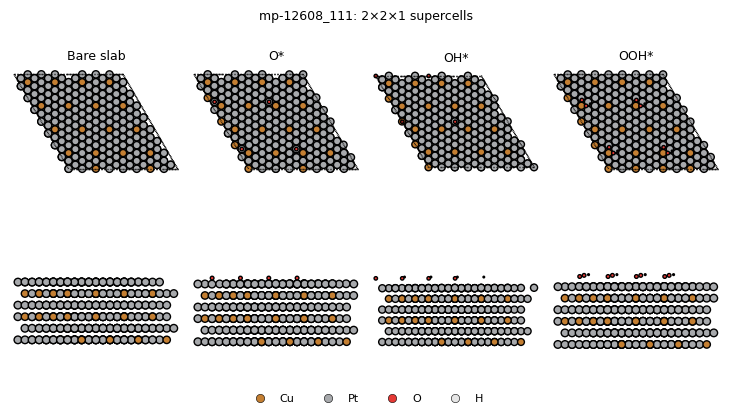

In [8]:
def save_publication_figure(
    figure: plt.Figure,
    output_stem: Path,
) -> None:
    output_stem.parent.mkdir(parents=True, exist_ok=True)

    figure.savefig(
        output_stem.with_suffix(".png"),
        dpi=600,
        bbox_inches="tight",
    )
    figure.savefig(
        output_stem.with_suffix(".pdf"),
        bbox_inches="tight",
    )
    figure.savefig(
        output_stem.with_suffix(".svg"),
        bbox_inches="tight",
    )


def plot_intermediate_structures(
    data_root: Path,
    surface_id: str,
    *,
    repeat: tuple[int, int, int] = SUPERCELL,
) -> plt.Figure:
    """Plot top and side views of colored repeated structures."""
    fig, axes = plt.subplots(
        2,
        4,
        figsize=(7.2, 4.0),
        constrained_layout=True,
    )

    legend_colors: dict[str, str] = {}

    for column, state in enumerate(SURFACE_STATES):
        atoms = read_contcar(
            data_root / surface_id / state / "CONTCAR"
        ).repeat(repeat)
        atoms.wrap()

        color_map = element_color_map(atoms)
        legend_colors.update(color_map)
        atom_colors = [
            color_map[element]
            for element in atoms.get_chemical_symbols()
        ]

        for row, rotation in enumerate(("0x,0y,0z", "-90x,0y,0z")):
            axis = axes[row, column]

            plot_atoms(
                atoms,
                axis,
                rotation=rotation,
                radii=0.55,
                colors=atom_colors,
                show_unit_cell=2 if row == 0 else 0,
            )
            axis.set_axis_off()

            if row == 0:
                axis.set_title(STATE_LABELS[state], fontsize=9)

            if column == 0:
                axis.set_ylabel(
                    "Top view" if row == 0 else "Side view",
                    fontsize=8,
                )

    handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="",
            markerfacecolor=color,
            markeredgecolor="black",
            markeredgewidth=0.4,
            markersize=6,
            label=element,
        )
        for element, color in legend_colors.items()
    ]

    fig.legend(
        handles=handles,
        loc="lower center",
        ncol=max(1, len(handles)),
        frameon=False,
        bbox_to_anchor=(0.5, -0.02),
        fontsize=8,
    )

    fig.suptitle(
        f"{surface_id}: {repeat[0]}×{repeat[1]}×{repeat[2]} supercells",
        fontsize=9,
    )
    return fig


structure_figure = plot_intermediate_structures(
    DATA_ROOT,
    CANDIDATE,
)

save_publication_figure(
    structure_figure,
    OUTPUT_DIR / f"{CANDIDATE}_intermediates_2x2x1",
)

plt.show()

## 8. Vacuum and solvent-aware adsorption Gibbs free energies

Each state is built directly from the last sigma-to-zero electronic energy and
the explicit VaspGibbs correction:

$$
G_{\mathrm{state}}
=
E_{\sigma\rightarrow 0,\mathrm{state}}
+
\left(G-E_{\mathrm{DFT}}\right)_{\mathrm{state}}.
$$

For example, a reported correction of

```text
| G - E_dft | -0.697441 eV |
```

is added to that state's `energy(sigma->0)` value.

The H₂ and H₂O references are always their **vacuum** free energies:

$$
G_{\mathrm{H_2}}^{\mathrm{vac}}
=
E_{\sigma\rightarrow0,\mathrm{H_2}}^{\mathrm{vac}}
+
\Delta G_{\mathrm{corr,H_2}},
$$

$$
G_{\mathrm{H_2O}}^{\mathrm{vac}}
=
E_{\sigma\rightarrow0,\mathrm{H_2O}}^{\mathrm{vac}}
+
\Delta G_{\mathrm{corr,H_2O}}.
$$

These same vacuum molecular references are used in both surface environments:

$$
G_{\mathrm{ref}}(\mathrm O^*)
=
G_{\mathrm{H_2O}}^{\mathrm{vac}}
-
G_{\mathrm{H_2}}^{\mathrm{vac}},
$$

$$
G_{\mathrm{ref}}(\mathrm{OH}^*)
=
G_{\mathrm{H_2O}}^{\mathrm{vac}}
-
\frac{1}{2}G_{\mathrm{H_2}}^{\mathrm{vac}},
$$

$$
G_{\mathrm{ref}}(\mathrm{OOH}^*)
=
2G_{\mathrm{H_2O}}^{\mathrm{vac}}
-
\frac{3}{2}G_{\mathrm{H_2}}^{\mathrm{vac}}.
$$

Vacuum adsorption uses the surface-state vacuum `OUTCAR`. Solvent-aware
adsorption uses the surface-state `Sol/OUTCAR`. In both cases the state-specific
vacuum `Freq_vac/VaspGibbs.md` correction and the same vacuum molecular
references are used.

In [9]:
def one_energy(
    table: pd.DataFrame,
    *,
    system: str,
    state: str,
    environment: str,
) -> pd.Series:
    selected = table[
        (table["system"] == system)
        & (table["state"] == state)
        & (table["environment"] == environment)
    ]

    if len(selected) != 1:
        raise ValueError(
            "Expected exactly one energy row for "
            f"{system}/{state}/{environment}; "
            f"found {len(selected)}."
        )

    return selected.iloc[0]


def vacuum_che_reference(
    table: pd.DataFrame,
    *,
    adsorbate: str,
) -> dict[str, float]:
    """
    Build a CHE reference using only vacuum H2 and H2O values.

    The returned reference is reused unchanged for vacuum and solvent
    adsorption calculations.
    """
    h2 = one_energy(
        table,
        system="H2",
        state="H2",
        environment="vacuum_reference",
    )
    h2o = one_energy(
        table,
        system="H2O",
        state="H2O",
        environment="vacuum_reference",
    )

    coefficients = {
        "O": (1.0, -1.0),
        "OH": (1.0, -0.5),
        "OOH": (2.0, -1.5),
    }
    n_h2o, n_h2 = coefficients[adsorbate]

    electronic_reference = (
        n_h2o * float(h2o["E_sigma0_eV"])
        + n_h2 * float(h2["E_sigma0_eV"])
    )
    correction_reference = (
        n_h2o * float(h2o["G_minus_Edft_eV"])
        + n_h2 * float(h2["G_minus_Edft_eV"])
    )
    gibbs_reference = (
        n_h2o * float(h2o["G_state_eV"])
        + n_h2 * float(h2["G_state_eV"])
    )

    return {
        "electronic_reference_eV": electronic_reference,
        "reference_correction_eV": correction_reference,
        "gibbs_reference_eV": gibbs_reference,
        "reference_environment": "vacuum H2/H2O",
    }


reference_rows = [
    {
        "adsorbate": adsorbate,
        **vacuum_che_reference(
            raw_energies,
            adsorbate=adsorbate,
        ),
    }
    for adsorbate in ADSORBATES
]
che_references = pd.DataFrame(reference_rows)
che_references.to_csv(
    OUTPUT_DIR / "02_CHE_vacuum_references.csv",
    index=False,
)

display(che_references)


adsorption_rows = []

for surface_id in (CANDIDATE, PT_REFERENCE):
    for environment in ("vacuum", "solvent"):
        slab = one_energy(
            raw_energies,
            system=surface_id,
            state="Slab",
            environment=environment,
        )

        for adsorbate in ADSORBATES:
            adsorbed = one_energy(
                raw_energies,
                system=surface_id,
                state=adsorbate,
                environment=environment,
            )
            reference = vacuum_che_reference(
                raw_energies,
                adsorbate=adsorbate,
            )

            delta_e_sigma0 = (
                float(adsorbed["E_sigma0_eV"])
                - float(slab["E_sigma0_eV"])
                - reference["electronic_reference_eV"]
            )
            delta_g_correction = (
                float(adsorbed["G_minus_Edft_eV"])
                - float(slab["G_minus_Edft_eV"])
                - reference["reference_correction_eV"]
            )
            delta_g_adsorption = (
                delta_e_sigma0 + delta_g_correction
            )

            # Independent total-G expression for an auditable closure check.
            delta_g_direct = (
                float(adsorbed["G_state_eV"])
                - float(slab["G_state_eV"])
                - reference["gibbs_reference_eV"]
            )

            adsorption_rows.append(
                {
                    "slab": surface_id,
                    "environment": environment,
                    "adsorbate": adsorbate,
                    "DeltaE_sigma0_ads_eV": delta_e_sigma0,
                    "DeltaG_correction_ads_eV": delta_g_correction,
                    "DeltaG_ads_eV": delta_g_adsorption,
                    "closure_error_eV": (
                        delta_g_adsorption - delta_g_direct
                    ),
                    "molecular_reference": (
                        reference["reference_environment"]
                    ),
                    "adsorbed_E_sigma0_eV": (
                        float(adsorbed["E_sigma0_eV"])
                    ),
                    "slab_E_sigma0_eV": (
                        float(slab["E_sigma0_eV"])
                    ),
                    "adsorbed_G_minus_Edft_eV": (
                        float(adsorbed["G_minus_Edft_eV"])
                    ),
                    "slab_G_minus_Edft_eV": (
                        float(slab["G_minus_Edft_eV"])
                    ),
                    "adsorbed_OUTCAR": adsorbed["source_OUTCAR"],
                    "slab_OUTCAR": slab["source_OUTCAR"],
                    "adsorbed_VaspGibbs": (
                        adsorbed["source_VaspGibbs"]
                    ),
                    "slab_VaspGibbs": slab["source_VaspGibbs"],
                }
            )

adsorption_gibbs = pd.DataFrame(adsorption_rows)

if not adsorption_gibbs["closure_error_eV"].abs().lt(1e-8).all():
    raise ArithmeticError(
        "The E_sigma0 + correction decomposition failed its closure check."
    )

vacuum_lookup = (
    adsorption_gibbs[
        adsorption_gibbs["environment"] == "vacuum"
    ]
    .set_index(["slab", "adsorbate"])["DeltaG_ads_eV"]
)

adsorption_gibbs["DeltaG_solvation_eV"] = [
    (
        row.DeltaG_ads_eV
        - float(vacuum_lookup.loc[(row.slab, row.adsorbate)])
        if row.environment == "solvent"
        else 0.0
    )
    for row in adsorption_gibbs.itertuples()
]

adsorption_gibbs.to_csv(
    OUTPUT_DIR / "03_adsorption_gibbs_free_energies.csv",
    index=False,
)

display(adsorption_gibbs)

,adsorbate,electronic_reference_eV,reference_correction_eV,gibbs_reference_eV,reference_environment
0,O,-7.196685,0.127768,-7.068917,vacuum H2/H2O
1,OH,-10.685913,0.105922,-10.579991,vacuum H2/H2O
2,OOH,-17.882598,0.233690,-17.648908,vacuum H2/H2O


,slab,environment,adsorbate,DeltaE_sigma0_ads_eV,DeltaG_correction_ads_eV,DeltaG_ads_eV,closure_error_eV,molecular_reference,adsorbed_E_sigma0_eV,slab_E_sigma0_eV,adsorbed_G_minus_Edft_eV,slab_G_minus_Edft_eV,adsorbed_OUTCAR,slab_OUTCAR,adsorbed_VaspGibbs,slab_VaspGibbs,DeltaG_solvation_eV
0,mp-12608_111,vacuum,O,1.274200,-0.052293,1.221907,-9.725554e-14,vacuum H2/H2O,-577.099103,-571.176618,-1.018660,-1.094135,/content/ML-accelerated-ORR/data/stageIII_vasp...,/content/ML-accelerated-ORR/data/stageIII_vasp...,/content/ML-accelerated-ORR/data/stageIII_vasp...,/content/ML-accelerated-ORR/data/stageIII_vasp...,0.000000
1,mp-12608_111,vacuum,OH,0.667253,0.109775,0.777027,-3.608225e-14,vacuum H2/H2O,-581.195279,-571.176618,-0.878439,-1.094135,/content/ML-accelerated-ORR/data/stageIII_vasp...,/content/ML-accelerated-ORR/data/stageIII_vasp...,/content/ML-accelerated-ORR/data/stageIII_vasp...,/content/ML-accelerated-ORR/data/stageIII_vasp...,0.000000
2,mp-12608_111,vacuum,OOH,3.573150,0.103033,3.676183,-8.704149e-14,vacuum H2/H2O,-585.486066,-571.176618,-0.757412,-1.094135,/content/ML-accelerated-ORR/data/stageIII_vasp...,/content/ML-accelerated-ORR/data/stageIII_vasp...,/content/ML-accelerated-ORR/data/stageIII_vasp...,/content/ML-accelerated-ORR/data/stageIII_vasp...,0.000000
3,mp-12608_111,solvent,O,1.261438,-0.052293,1.209145,-9.725554e-14,vacuum H2/H2O,-577.068031,-571.132784,-1.018660,-1.094135,/content/ML-accelerated-ORR/data/stageIII_vasp...,/content/ML-accelerated-ORR/data/stageIII_vasp...,/content/ML-accelerated-ORR/data/stageIII_vasp...,/content/ML-accelerated-ORR/data/stageIII_vasp...,-0.012762
4,mp-12608_111,solvent,OH,0.529705,0.109775,0.639480,-3.608225e-14,vacuum H2/H2O,-581.288992,-571.132784,-0.878439,-1.094135,/content/ML-accelerated-ORR/data/stageIII_vasp...,/content/ML-accelerated-ORR/data/stageIII_vasp...,/content/ML-accelerated-ORR/data/stageIII_vasp...,/content/ML-accelerated-ORR/data/stageIII_vasp...,-0.137547
5,mp-12608_111,solvent,OOH,3.358954,0.103033,3.461987,-8.704149e-14,vacuum H2/H2O,-585.656428,-571.132784,-0.757412,-1.094135,/content/ML-accelerated-ORR/data/stageIII_vasp...,/content/ML-accelerated-ORR/data/stageIII_vasp...,/content/ML-accelerated-ORR/data/stageIII_vasp...,/content/ML-accelerated-ORR/data/stageIII_vasp...,-0.214196
6,mp-126_111,vacuum,O,1.224048,-0.089057,1.134992,-3.419487e-14,vacuum H2/H2O,-336.295836,-330.323199,-0.658729,-0.697441,/content/ML-accelerated-ORR/data/stageIII_vasp...,/content/ML-accelerated-ORR/data/stageIII_vasp...,/content/ML-accelerated-ORR/data/stageIII_vasp...,/content/ML-accelerated-ORR/data/stageIII_vasp...,0.000000
7,mp-126_111,vacuum,OH,0.693762,0.168104,0.861866,-3.896883e-14,vacuum H2/H2O,-340.315350,-330.323199,-0.423415,-0.697441,/content/ML-accelerated-ORR/data/stageIII_vasp...,/content/ML-accelerated-ORR/data/stageIII_vasp...,/content/ML-accelerated-ORR/data/stageIII_vasp...,/content/ML-accelerated-ORR/data/stageIII_vasp...,0.000000
8,mp-126_111,vacuum,OOH,3.554457,0.094954,3.649412,-8.881784e-15,vacuum H2/H2O,-344.651339,-330.323199,-0.368797,-0.697441,/content/ML-accelerated-ORR/data/stageIII_vasp...,/content/ML-accelerated-ORR/data/stageIII_vasp...,/content/ML-accelerated-ORR/data/stageIII_vasp...,/content/ML-accelerated-ORR/data/stageIII_vasp...,0.000000
9,mp-126_111,solvent,O,1.209895,-0.089057,1.120839,-3.419487e-14,vacuum H2/H2O,-336.263448,-330.276658,-0.658729,-0.697441,/content/ML-accelerated-ORR/data/stageIII_vasp...,/content/ML-accelerated-ORR/data/stageIII_vasp...,/content/ML-accelerated-ORR/data/stageIII_vasp...,/content/ML-accelerated-ORR/data/stageIII_vasp...,-0.014153


## 9. ORR limiting potential, PDS, and overpotential

For the four-electron associative ORR pathway:

\[
U_1=4.92-\Delta G_{\mathrm{OOH}},
\qquad
U_2=\Delta G_{\mathrm{OOH}}-\Delta G_{\mathrm O},
\]

\[
U_3=\Delta G_{\mathrm O}-\Delta G_{\mathrm{OH}},
\qquad
U_4=\Delta G_{\mathrm{OH}}.
\]

The limiting potential and thermodynamic overpotential are

\[
U_L=\min(U_1,U_2,U_3,U_4),
\qquad
\eta_{\mathrm{ORR}}=1.23-U_L.
\]

The step associated with the minimum \(U_i\) is reported as the PDS.

In [10]:
def calculate_orr(
    adsorption: pd.DataFrame,
) -> pd.DataFrame:
    rows = []

    for (surface_id, environment), group in adsorption.groupby(
        ["slab", "environment"],
        sort=True,
    ):
        values = group.set_index("adsorbate")["DeltaG_ads_eV"]

        missing = [
            adsorbate
            for adsorbate in ADSORBATES
            if adsorbate not in values.index
        ]

        if missing:
            raise ValueError(
                f"{surface_id}/{environment} is missing {missing}."
            )

        g_o = float(values["O"])
        g_oh = float(values["OH"])
        g_ooh = float(values["OOH"])

        steps = {
            "U1": TOTAL_ORR_FREE_ENERGY_EV - g_ooh,
            "U2": g_ooh - g_o,
            "U3": g_o - g_oh,
            "U4": g_oh,
        }

        pds_key = min(steps, key=steps.get)
        limiting_potential = steps[pds_key]

        rows.append(
            {
                "slab": surface_id,
                "environment": environment,
                "G_O_eV": g_o,
                "G_OH_eV": g_oh,
                "G_OOH_eV": g_ooh,
                "U1_O2_to_OOH_V": steps["U1"],
                "U2_OOH_to_O_V": steps["U2"],
                "U3_O_to_OH_V": steps["U3"],
                "U4_OH_to_H2O_V": steps["U4"],
                "U_L_ORR_V": limiting_potential,
                "eta_ORR_V": (
                    EQUILIBRIUM_POTENTIAL_V - limiting_potential
                ),
                "PDS_key": pds_key,
                "PDS": PDS_LABELS[pds_key],
            }
        )

    return pd.DataFrame(rows)


orr_results = calculate_orr(adsorption_gibbs)

pt_eta = (
    orr_results[
        orr_results["slab"] == PT_REFERENCE
    ]
    .set_index("environment")["eta_ORR_V"]
)

orr_results["Pt_reference"] = PT_REFERENCE
orr_results["Pt_eta_ORR_V"] = [
    float(pt_eta.loc[environment])
    for environment in orr_results["environment"]
]
orr_results["delta_eta_vs_Pt_V"] = (
    orr_results["eta_ORR_V"] - orr_results["Pt_eta_ORR_V"]
)
orr_results["better_than_Pt"] = (
    orr_results["delta_eta_vs_Pt_V"] < 0.0
)

orr_results = orr_results.sort_values(
    ["environment", "eta_ORR_V", "slab"]
).reset_index(drop=True)

orr_results.to_csv(
    OUTPUT_DIR / "04_ORR_overpotential_and_PDS.csv",
    index=False,
)

display(
    orr_results[
        [
            "slab",
            "environment",
            "U_L_ORR_V",
            "eta_ORR_V",
            "PDS",
            "delta_eta_vs_Pt_V",
            "better_than_Pt",
        ]
    ]
)

,slab,environment,U_L_ORR_V,eta_ORR_V,PDS,delta_eta_vs_Pt_V,better_than_Pt
0,mp-12608_111,solvent,0.569665,0.660335,O* → OH*,-0.171645,True
1,mp-126_111,solvent,0.398020,0.831980,O* → OH*,0.000000,False
2,mp-12608_111,vacuum,0.444880,0.785120,O* → OH*,-0.171754,True
3,mp-126_111,vacuum,0.273126,0.956874,O* → OH*,0.000000,False


## 10. Vacuum and solvent ORR free-energy diagrams

The diagrams are shown at the equilibrium potential \(U=1.23\ \mathrm{V}\).
At this potential, the largest uphill proton-electron-transfer step corresponds
to the thermodynamic overpotential. The PDS is highlighted.

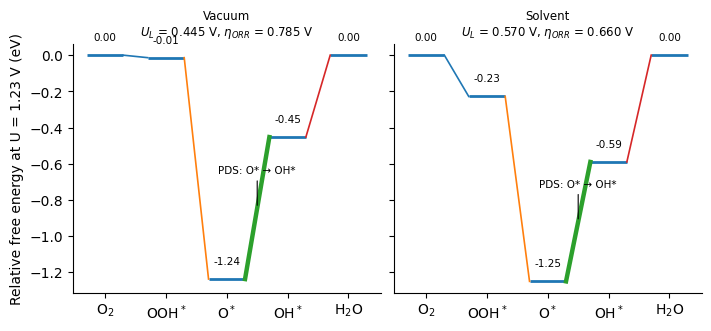

In [11]:
def reaction_levels_at_potential(
    row: pd.Series,
    potential_v: float,
) -> list[float]:
    step_potentials = np.array(
        [
            row["U1_O2_to_OOH_V"],
            row["U2_OOH_to_O_V"],
            row["U3_O_to_OH_V"],
            row["U4_OH_to_H2O_V"],
        ],
        dtype=float,
    )

    step_free_energies = -step_potentials + potential_v

    levels = [0.0]

    for step_delta_g in step_free_energies:
        levels.append(levels[-1] + float(step_delta_g))

    return levels


def plot_free_energy_diagrams(
    results: pd.DataFrame,
    *,
    surface_id: str,
    potential_v: float = 1.23,
) -> plt.Figure:
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(7.0, 3.2),
        sharey=True,
        constrained_layout=True,
    )

    state_labels = [
        r"$\mathrm{O_2}$",
        r"$\mathrm{OOH^*}$",
        r"$\mathrm{O^*}$",
        r"$\mathrm{OH^*}$",
        r"$\mathrm{H_2O}$",
    ]

    for axis, environment in zip(axes, ("vacuum", "solvent")):
        selected = results[
            (results["slab"] == surface_id)
            & (results["environment"] == environment)
        ]

        if len(selected) != 1:
            raise ValueError(
                f"No unique ORR result for {surface_id}/{environment}."
            )

        row = selected.iloc[0]
        levels = reaction_levels_at_potential(row, potential_v)

        pds_index = {
            "U1": 0,
            "U2": 1,
            "U3": 2,
            "U4": 3,
        }[row["PDS_key"]]

        for index, level in enumerate(levels):
            axis.hlines(
                level,
                index - 0.30,
                index + 0.30,
                linewidth=2.0,
            )
            axis.text(
                index,
                level + 0.07,
                f"{level:.2f}",
                ha="center",
                va="bottom",
                fontsize=7.5,
            )

        for index in range(4):
            linewidth = 3.2 if index == pds_index else 1.2
            axis.plot(
                [index + 0.30, index + 0.70],
                [levels[index], levels[index + 1]],
                linewidth=linewidth,
            )

        axis.annotate(
            f"PDS: {row['PDS']}",
            xy=(
                pds_index + 0.5,
                (levels[pds_index] + levels[pds_index + 1]) / 2,
            ),
            xytext=(0, 25),
            textcoords="offset points",
            ha="center",
            fontsize=7.5,
            arrowprops={
                "arrowstyle": "-",
                "linewidth": 0.8,
            },
        )

        axis.set_xticks(range(5), state_labels)
        axis.set_title(
            f"{environment.capitalize()}\n"
            f"$U_L$ = {row['U_L_ORR_V']:.3f} V, "
            f"$\\eta_{{ORR}}$ = {row['eta_ORR_V']:.3f} V",
            fontsize=8.5,
        )
        axis.spines[["top", "right"]].set_visible(False)

    axes[0].set_ylabel(
        f"Relative free energy at U = {potential_v:.2f} V (eV)"
    )

    return fig


free_energy_figure = plot_free_energy_diagrams(
    orr_results,
    surface_id=CANDIDATE,
    potential_v=EQUILIBRIUM_POTENTIAL_V,
)

save_publication_figure(
    free_energy_figure,
    OUTPUT_DIR / f"{CANDIDATE}_vacuum_and_solvent_ORR",
)

plt.show()

## 11. Publication overpotential comparison with PDS labels

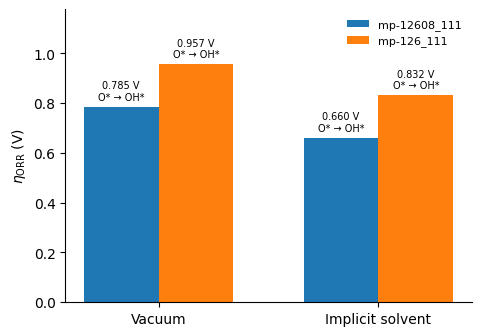

In [12]:
def plot_overpotential_comparison(
    results: pd.DataFrame,
    *,
    candidate: str,
    pt_reference: str,
) -> plt.Figure:
    environments = ("vacuum", "solvent")
    surfaces = (candidate, pt_reference)

    x = np.arange(len(environments))
    width = 0.34

    fig, axis = plt.subplots(
        figsize=(4.7, 3.25),
        constrained_layout=True,
    )

    for surface_index, surface_id in enumerate(surfaces):
        values = []
        pds_labels = []

        for environment in environments:
            row = results[
                (results["slab"] == surface_id)
                & (results["environment"] == environment)
            ].iloc[0]

            values.append(float(row["eta_ORR_V"]))
            pds_labels.append(str(row["PDS"]))

        positions = x + (surface_index - 0.5) * width

        bars = axis.bar(
            positions,
            values,
            width,
            label=surface_id,
        )

        for bar, value, pds in zip(bars, values, pds_labels):
            axis.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.018,
                f"{value:.3f} V\n{pds}",
                ha="center",
                va="bottom",
                fontsize=7,
            )

    axis.set_xticks(x, ["Vacuum", "Implicit solvent"])
    axis.set_ylabel(r"$\eta_{\mathrm{ORR}}$ (V)")
    axis.legend(frameon=False, fontsize=8)
    axis.spines[["top", "right"]].set_visible(False)

    upper_limit = results["eta_ORR_V"].max() + 0.22
    axis.set_ylim(0.0, upper_limit)

    return fig


overpotential_figure = plot_overpotential_comparison(
    orr_results,
    candidate=CANDIDATE,
    pt_reference=PT_REFERENCE,
)

save_publication_figure(
    overpotential_figure,
    OUTPUT_DIR / "candidate_vs_Pt_ORR_overpotential",
)

plt.show()

## 12. Export provenance and download all results

In [13]:
run_metadata = {
    "repository": REPO_URL,
    "repository_ref": REPO_REF,
    "data_root": str(DATA_ROOT),
    "candidate": CANDIDATE,
    "pt_reference": PT_REFERENCE,
    "required_files": file_audit["file"].tolist(),
    "electronic_energy": (
        "last energy(sigma->0) parsed directly from each OUTCAR"
    ),
    "force_and_frame_parser": (
        "ASE vasp-out used only for optional force/frame diagnostics"
    ),
    "structure_parser": "ASE vasp CONTCAR reader",
    "thermal_correction": (
        "explicit G - E_dft from each vacuum Freq_vac/VaspGibbs.md"
    ),
    "state_free_energy": (
        "G_state = E_sigma0 + (G - E_dft)"
    ),
    "molecular_reference": (
        "vacuum H2 and H2O used unchanged for vacuum and solvent surfaces"
    ),
    "solvent_convention": (
        "Sol/OUTCAR sigma0 energies for surface states; "
        "vacuum state corrections and vacuum molecular references retained"
    ),
    "visualization_supercell": list(SUPERCELL),
    "visualization_colors": PREFERRED_ELEMENT_COLORS,
    "orr_equilibrium_potential_V": EQUILIBRIUM_POTENTIAL_V,
    "overall_ORR_free_energy_eV": TOTAL_ORR_FREE_ENERGY_EV,
}

(OUTPUT_DIR / "05_run_metadata.json").write_text(
    json.dumps(run_metadata, indent=2) + "\n",
    encoding="utf-8",
)

archive_path = shutil.make_archive(
    str(OUTPUT_DIR),
    "zip",
    root_dir=OUTPUT_DIR,
)

print("Results directory:", OUTPUT_DIR)
print("Download archive: ", archive_path)

for path in sorted(OUTPUT_DIR.iterdir()):
    print(
        f"{path.name:55s} "
        f"{path.stat().st_size / 1024:.1f} kB"
    )

if IN_COLAB:
    from google.colab import files

    files.download(archive_path)

Results directory: /content/ML-accelerated-ORR/outputs/stageIII_vasp_demo
Download archive:  /content/ML-accelerated-ORR/outputs/stageIII_vasp_demo.zip
01_raw_vasp_energies.csv                                7.4 kB
02_CHE_vacuum_references.csv                            0.3 kB
03_adsorption_gibbs_free_energies.csv                   6.3 kB
04_ORR_overpotential_and_PDS.csv                        1.2 kB
05_run_metadata.json                                    2.4 kB
candidate_vs_Pt_ORR_overpotential.pdf                   16.0 kB
candidate_vs_Pt_ORR_overpotential.png                   140.8 kB
candidate_vs_Pt_ORR_overpotential.svg                   29.8 kB
mp-12608_111_intermediates_2x2x1.pdf                    438.9 kB
mp-12608_111_intermediates_2x2x1.png                    1588.9 kB
mp-12608_111_intermediates_2x2x1.svg                    2989.2 kB
mp-12608_111_vacuum_and_solvent_ORR.pdf                 20.2 kB
mp-12608_111_vacuum_and_solvent_ORR.png                 273.2 kB
mp-12608_111_v

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Output files

The notebook exports:

```text
outputs/stageIII_vasp_demo/
├── 01_raw_vasp_energies.csv
├── 02_CHE_vacuum_references.csv
├── 03_adsorption_gibbs_free_energies.csv
├── 04_ORR_overpotential_and_PDS.csv
├── 05_run_metadata.json
├── mp-12608_111_intermediates_2x2x1.{png,pdf,svg}
├── mp-12608_111_vacuum_and_solvent_ORR.{png,pdf,svg}
└── candidate_vs_Pt_ORR_overpotential.{png,pdf,svg}
```

The raw table reports `E_sigma0`, `G - E_dft`, and their sum separately.
The adsorption table reports the electronic and correction contributions,
the fixed vacuum molecular reference convention, and a numerical closure test.

Licensed VASP `POTCAR` files are not required and must not be redistributed.